<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

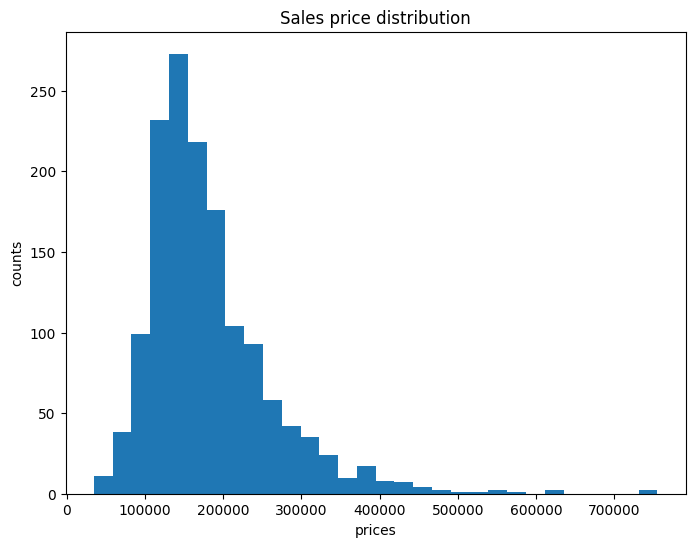

<class 'pandas.core.series.Series'>
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
dtype: int64
numerical features: 36
categorical features: 43
scores: [0.11655537 0.14864135 0.1307262  0.1175455  0.18437571]
meanmscore: 0.13956882783696525
prediction: [114196.61832569 150227.52761222 171308.50002363 ... 160280.60760332
 110945.46199541 226266.77992834]


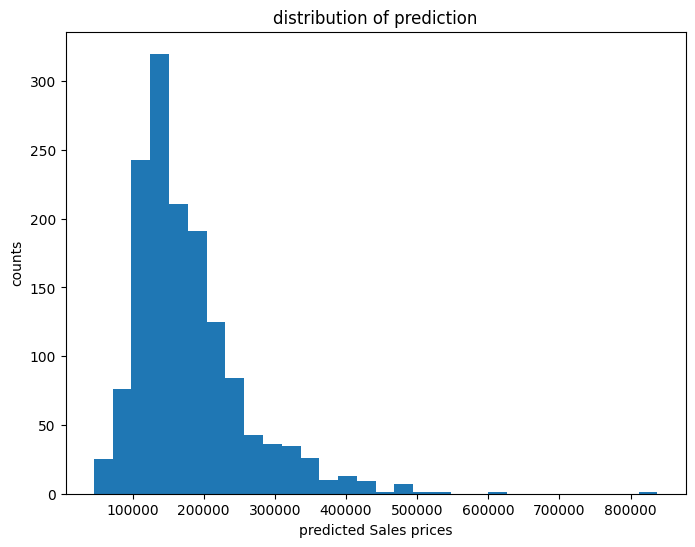

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
#=======================================================
#Load data

train_df =pd.read_csv('/content/train.csv')
test_df=pd.read_csv('/content/test.csv')
train_df .info()
train_df .head(5)
print("Shape of train data is:",train_df .shape)
print("Shape of test data is:",test_df .shape)

#=======================================================
#Check target column

print(train_df['SalePrice'].describe())
#25% of houses cost LESS than about 129,975.


#sns.histplot(train_df['SalePrice'])
plt.figure(figsize=(8,6))
plt.title("Sales price distribution")
plt.xlabel("prices")
plt.ylabel("counts")
plt.hist(train_df['SalePrice'],bins=30) #to see the distribution of target col
plt.show()

#=======================================================
#Check misshing values

missing=train_df .isna().sum().sort_values(ascending=False)
print(type(missing)) #<class 'pandas.core.series.Series'>
print(missing[missing>20])

#=======================================================
#Split features and target

x=train_df.drop(columns=["SalePrice","Id"])
#y=train_df["SalePrice"]
y=np.log1p(train_df["SalePrice"]) #compress numbers preventing large values dominate training, handle log(0)
#the target distribution is skewed.
x_test=test_df.drop(columns="Id")
test_id=test_df["Id"]

#=======================================================
#Separate numerical and categorical features

numerical_features=x.select_dtypes(include=["int64","float64"]).columns
categorical_features=x.select_dtypes(include=["object"]).columns

print("numerical features:",len(numerical_features))
print("categorical features:",len(categorical_features))

#=======================================================
#Pipeline for preprocessing data
numeric_preprocessor=Pipeline(steps=[("imputation_mean", SimpleImputer(missing_values=np.nan,strategy="mean"))
                                     ,("scaler", StandardScaler())
                                      ])
categorical_preprocessor=Pipeline(steps=[("imputation_constant", SimpleImputer(fill_value="missing",strategy="constant"))
                                     ,("onehot", OneHotEncoder(handle_unknown="ignore"))# instead of manually doing reindex we use handle unknown
                                      ])
preprocessor=ColumnTransformer([("numerical",numeric_preprocessor,numerical_features)
                                ,("categorical",categorical_preprocessor,categorical_features)])

Ridge_model=Pipeline([("preprocessor",preprocessor)
                    ,("model", Ridge(alpha=10))#regularization strength
                    ])

#crosee_val_score evaluates model quality,not train yet
scores=-cross_val_score(
                      Ridge_model
                      ,x
                      ,y
                      ,scoring="neg_root_mean_squared_error"
                      ,cv=5)#using negative RMSE BECAUSE SKLEARN RETURNs -rmse, the higher the better


print("scores:",scores)
print("meanmscore:", scores.mean())

#train model on the whole dataset
model=Ridge_model.fit(x,y)

#predict on unseen data
prediction=model.predict(x_test) #automatically preprocess test data
#reverse y back to the normal values
prediction=np.expm1(prediction)
print("prediction:",prediction )

#create submission
submission=pd.DataFrame({'Id':test_id,'SalePrice':prediction})
submission.to_csv('submission.csv',index=False)

#plot the histogram of predictions
plt.figure(figsize=(8,6))
plt.title("distribution of prediction")
plt.xlabel("predicted Sales prices")
plt.ylabel("counts")
plt.hist(prediction,bins=30)
plt.show()

Ridge regression formula

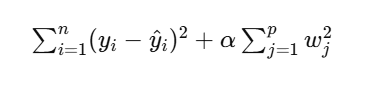

### **Trying Linear regression**

scores: [0.13752061 0.16656931 0.16875784 0.11099589 0.19958216]
scores_mean: 0.15668516311282304
lr predictions [121598.09358093 167031.00491325 182914.99030175 ... 176727.94372525
 114401.49361509 220935.19749712]


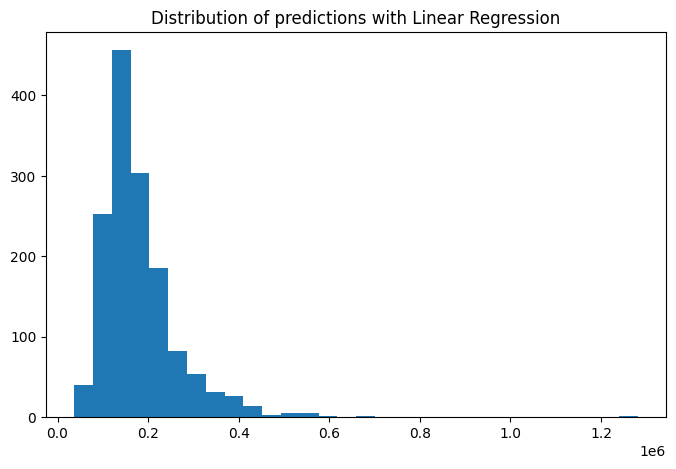

In [ ]:
from sklearn.linear_model import LinearRegression

linear_reg=Pipeline([("preprocessor", preprocessor),
                     ("model",LinearRegression())

                     ])

LR_scores= -cross_val_score( #use minus before to convert it into positive scores
   linear_reg
   ,x
   ,y
   ,cv=5
   ,scoring="neg_root_mean_squared_error"

)

print("scores:",LR_scores)
print("scores_mean:",LR_scores.mean())

lr_model=linear_reg.fit(x,y)

lr_predictions=lr_model.predict(x_test)
lr_predictions=np.expm1(lr_predictions)

#create submission
Lr_submission=pd.DataFrame({"Id":test_id, "SalePrice": lr_predictions})
Lr_submission.to_csv("Linear_reg_submission.csv",index=False)

print("lr predictions",lr_predictions)

plt.figure(figsize=(8,5))
plt.title("Distribution of predictions with Linear Regression")
plt.hist(lr_predictions, bins=30)
plt.show()



## **RandomForestRegressor**

RF_scores [0.13851806 0.15637874 0.14405341 0.12989725 0.14874323]
RF_scores_mean 0.14351813901093632
RF_predictions [124080.85593658 155267.68760285 179509.29231942 ... 153006.32658611
 112859.28244119 234619.07041926]


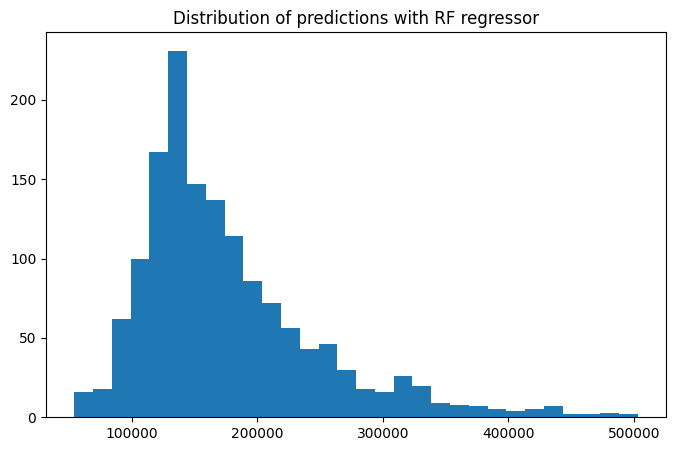

In [ ]:
from sklearn.ensemble import RandomForestRegressor
RF=Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor (n_estimators=100,random_state=42))
])

RF_scores= -cross_val_score(
    RF_model
    ,x
    ,y
    ,scoring="neg_root_mean_squared_error"
    ,cv=5

)

print("RF_scores",RF_scores)
print("RF_scores_mean",RF_scores.mean())

RF_model=RF.fit(x,y)
RF_predictions=RF_model.predict(x_test)
RF_predictions=np.expm1(RF_predictions)

print("RF_predictions", RF_predictions)

#create submission
RF_submission=pd.DataFrame({"Id":test_id, "SalePrice": RF_predictions})
RF_submission.to_csv("RF_submission.csv",index=False)

plt.figure(figsize=(8,5))
plt.title("Distribution of predictions with RF regressor")
plt.hist(RF_predictions, bins=30)
plt.show()

## **GradientBoostingRegressor**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_pipe=Pipeline([
    ('preprocessor', preprocessor),
    ('model',GradientBoostingRegressor(random_state=42))
])

gb_scores= -cross_val_score(
    gb_pipe
    ,x
    ,y
    ,scoring="neg_root_mean_squared_error"
    ,cv=5
)

print("gb_scores_mean", gb_scores.mean())

gb_model=gb_pipe.fit(x,y)
gb_predictions=gb_model.predict(x_test)
gb_predictions=np.expm1(gb_predictions)

gb_submission=pd.DataFrame({'Id': test_id, 'SalePrice': gb_predictions})
gb_submission.to_csv('gb_predictions.csv',index=False)

gb_scores_mean 0.12558076281920463
